# Word Embeddings from Scratch — Skip-gram with Negative Sampling (SGNS)

**Vishal Sigdel** · MTech NLP

This notebook implements the SGNS algorithm (Mikolov et al., 2013) end-to-end in pure NumPy,
following the 8-step procedure below.

| Step | What it does | Section |
|---|---|---|
| 1 | Assemble corpus | [§1](#1) |
| 2 | Define vocabulary size $M$ | [§2](#2) |
| 3 | Choose context window $C$ | [§3](#3) |
| 4 | Build co-occurrence dictionary | [§4](#4) |
| 5 | Choose embedding size $N$ | [§5](#5) |
| 6 | Initialize tables $E$ (target) and $U$ (context) | [§6](#6) |
| 7 | Train with sliding window + negative sampling | [§7](#7) |
| 8 | Keep $E$, discard $U$ | [§8](#8) |

### The objective

For a **positive** pair (target $w$, true context $c$) and $k$ **negative** samples $c_1 \dots c_k$
drawn from a noise distribution, SGNS maximises:

$$\log \sigma(\mathbf{e}_w \cdot \mathbf{u}_c) \;+\; \sum_{i=1}^{k} \log \sigma(-\,\mathbf{e}_w \cdot \mathbf{u}_{c_i})$$

Intuition: push the dot product of a real (word, context) pair toward $+\infty$ (sigmoid $\to 1$),
and push the dot product of fake pairs toward $-\infty$ (sigmoid $\to 0$). Words that keep the same
company end up with similar vectors.

In [1]:
import collections
import gzip
import hashlib
import json
import math
import pathlib
import random
import re
import shutil
import time
import urllib.request
import zipfile
from dataclasses import dataclass, asdict, field
from typing import Iterable, Iterator, Sequence

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

HERE = pathlib.Path.cwd()
ARTIFACTS = HERE / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
CORPUS_PATH = HERE / "corpus.txt"

print(f"numpy      {np.__version__}")
print(f"workdir    {HERE}")
print(f"artifacts  {ARTIFACTS}")

numpy      2.5.1
workdir    /home/vishal/Classroom/MTech-NLP/SKIPgram
artifacts  /home/vishal/Classroom/MTech-NLP/SKIPgram/artifacts


/home/vishal/Classroom/MTech-NLP/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Hyperparameters

All tunable knobs live in one dataclass so the whole run is reproducible and auditable.
The defaults are the ones from the original `word2vec` release, scaled down to run on a laptop
in a few minutes.

In [2]:
@dataclass
class Config:
    # --- Step 2: vocabulary ---
    vocab_size: int = 50_000      # M — keep top-M frequent word types
    min_count: int = 5            # drop anything rarer than this (typos, hapax legomena)
    lowercase: bool = True        # "The" and "the" are the same word
    keep_numbers: bool = False    # map every digit run to a single <num> token

    # --- Step 3: context window ---
    window: int = 2               # C — 2 left + 2 right, so a 2C+1 = 5-word window
    dynamic_window: bool = True   # sample b ~ U{1..C} per centre word (word2vec's implicit
                                  # distance weighting: near words are sampled more often)

    # --- Step 5: embedding size ---
    dim: int = 100                # N — 300 in the paper; 100 is plenty for a course corpus

    # --- Step 7: training ---
    negatives: int = 5            # k negative samples per positive pair
    epochs: int = 5               # 3-50 in the procedure
    lr: float = 0.025             # initial learning rate
    min_lr_frac: float = 1e-4     # linearly decay lr down to lr * min_lr_frac
    batch_pairs: int = 4096       # centre words processed per vectorised update
    subsample_t: float = 1e-4     # frequent-word subsampling threshold (0 disables)
    ns_power: float = 0.75        # unigram^0.75 noise distribution exponent
    max_exp: float = 6.0          # clip dot products to +/- this before sigmoid

    seed: int = SEED

    def save(self, path: pathlib.Path) -> None:
        path.write_text(json.dumps(asdict(self), indent=2))

CFG = Config()
CFG

Config(vocab_size=50000, min_count=5, lowercase=True, keep_numbers=False, window=2, dynamic_window=True, dim=100, negatives=5, epochs=5, lr=0.025, min_lr_frac=0.0001, batch_pairs=4096, subsample_t=0.0001, ns_power=0.75, max_exp=6.0, seed=42)

<a id="1"></a>
## Step 1 — Assemble the corpus

> *Use large text sources like Wikipedia or news articles. The corpus defines the vocabulary and
> the word-usage patterns the embeddings will learn.*

We use **text8**: the first 100 MB of a 2006 English Wikipedia dump, lowercased, stripped of
markup and punctuation. It is the canonical word2vec benchmark corpus — ~17 M tokens, ~250 K word
types — which makes results comparable to published numbers.

The cell below downloads it once (31 MB zipped) and writes plain text to `corpus.txt`.
If `corpus.txt` already exists, nothing is downloaded — drop in your own corpus to use it instead.

`text8` ships as a **single 100 MB line** with no punctuation and no capitalisation, which no
editor will open comfortably. The cell below re-flows it on the way to disk: words are wrapped at
`WRAP_WIDTH` characters and a blank line is inserted every `PARA_LINES` lines. This is a
**whitespace-only** transformation — no token is added, removed or altered, so the word sequence
the model trains on is identical. The reader (`stream_tokens`) is line-based, so it is unaffected.


In [3]:
TEXT8_URL = "http://mattmahoney.net/dc/text8.zip"
TEXT8_SHA256 = "a6640522afe85d1963ad56c05b0ede0a0c000dddc9671758a6cc09b7a38e5232"

WRAP_WIDTH = 88        # characters per line
PARA_LINES = 12        # blank line inserted after this many wrapped lines


def _sha256(path: pathlib.Path, chunk: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with path.open("rb") as fh:
        while block := fh.read(chunk):
            h.update(block)
    return h.hexdigest()


def wrap_stream(words: Iterable[str], out, width: int = WRAP_WIDTH,
                para_lines: int = PARA_LINES) -> tuple[int, int]:
    """Write `words` to `out` as wrapped lines grouped into blank-line-separated blocks.

    Whitespace only — no token is added, removed or altered, so the training data is
    byte-for-byte the same sequence of words as the unwrapped original.
    """
    line: list[str] = []
    length = 0
    n_lines = n_words = 0

    for w in words:
        # +1 for the space that will join this word to the previous one
        if line and length + 1 + len(w) > width:
            out.write(" ".join(line) + "\n")
            n_lines += 1
            if n_lines % para_lines == 0:
                out.write("\n")
            line, length = [], 0
        line.append(w)
        length += len(w) + (1 if length else 0)
        n_words += 1

    if line:
        out.write(" ".join(line) + "\n")
        n_lines += 1
    return n_lines, n_words


def download_text8(dest: pathlib.Path) -> pathlib.Path:
    """Fetch text8, then write it to `dest` wrapped into readable paragraphs. Idempotent."""
    if dest.exists():
        print(f"corpus already present: {dest} ({dest.stat().st_size / 1e6:.1f} MB)")
        return dest

    zip_path = ARTIFACTS / "text8.zip"
    if not zip_path.exists():
        print(f"downloading {TEXT8_URL} ...")
        with urllib.request.urlopen(TEXT8_URL) as resp, zip_path.open("wb") as out:
            total = int(resp.headers.get("Content-Length", 0))
            with tqdm(total=total, unit="B", unit_scale=True, desc="text8.zip") as bar:
                while block := resp.read(1 << 16):
                    out.write(block)
                    bar.update(len(block))

    digest = _sha256(zip_path)
    if digest != TEXT8_SHA256:
        print(f"WARNING: sha256 mismatch\n  got      {digest}\n  expected {TEXT8_SHA256}")

    # text8 ships as a single 100 MB line. Re-flow it into wrapped paragraphs so the file
    # can actually be opened in an editor, streaming so memory stays flat.
    print("unpacking and wrapping ...")
    with zipfile.ZipFile(zip_path) as zf, zf.open("text8") as src, \
            dest.open("w", encoding="utf-8") as out:

        def word_stream() -> Iterator[str]:
            tail = ""
            with tqdm(unit="B", unit_scale=True, desc="wrapping") as bar:
                while block := src.read(1 << 20):
                    bar.update(len(block))
                    text = tail + block.decode("utf-8", errors="ignore")
                    parts = text.split(" ")
                    tail = parts.pop()          # last piece may be a half-read word
                    yield from (p for p in parts if p)
            if tail:
                yield tail

        n_lines, n_words = wrap_stream(word_stream(), out)

    print(f"wrote {dest} ({dest.stat().st_size / 1e6:.1f} MB): "
          f"{n_words:,} words in {n_lines:,} lines")
    return dest


download_text8(CORPUS_PATH)


corpus already present: /home/vishal/Classroom/MTech-NLP/SKIPgram/corpus.txt (100.1 MB)


PosixPath('/home/vishal/Classroom/MTech-NLP/SKIPgram/corpus.txt')

In [4]:
# Peek at the corpus. The file is stored wrapped at WRAP_WIDTH characters with a blank line
# every PARA_LINES lines, purely so it is readable — the token sequence is unchanged.
with CORPUS_PATH.open("r", encoding="utf-8") as fh:
    for _ in range(14):
        print(fh.readline().rstrip("\n"))


anarchism originated as a term of abuse first used against early working class radicals
including the diggers of the english revolution and the sans culottes of the french
revolution whilst the term is still used in a pejorative way to describe any act that
used violent means to destroy the organization of society it has also been taken up as a
positive label by self defined anarchists the word anarchism is derived from the greek
without archons ruler chief king anarchism as a political philosophy is the belief that
rulers are unnecessary and should be abolished although there are differing
interpretations of what this means anarchism also refers to related social movements
that advocate the elimination of authoritarian institutions particularly the state the
word anarchy as most anarchists use it does not imply chaos nihilism or anomie but
rather a harmonious anti authoritarian society in place of what are regarded as
authoritarian political structures and coercive economic institutio

### Tokenisation

> *Decide how to treat punctuation, symbols and capitalisation.*

Our normalisation policy, all driven by `Config`:

* **lowercase** — collapse `The`/`the`/`THE` into one type.
* **punctuation & symbols** — dropped. They carry little distributional signal at this scale and
  would each eat a vocabulary slot.
* **numbers** — every digit run collapses to `<num>`. Otherwise `1994`, `1995`, `1996` … each
  become separate rare types that only add noise.

`stream_tokens` is a **generator**: it reads the file line by line and yields tokens one at a time,
so peak memory stays flat no matter how big the corpus grows.

In [5]:
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?|\d+")

def normalise(text: str, cfg: Config = CFG) -> list[str]:
    """Turn a raw string into a list of tokens under the config's policy."""
    if cfg.lowercase:
        text = text.lower()
    tokens = TOKEN_RE.findall(text)
    if not cfg.keep_numbers:
        tokens = ["<num>" if tok[0].isdigit() else tok for tok in tokens]
    return tokens

def stream_tokens(path: pathlib.Path, cfg: Config = CFG) -> Iterator[str]:
    """Yield tokens one at a time; never holds the whole corpus in memory."""
    with path.open("r", encoding="utf-8", errors="ignore") as fh:
        for line in fh:
            yield from normalise(line, cfg)

print(normalise("The Anarchists' 1st meeting in 1872 was, arguably, DISORGANISED!"))

['the', 'anarchists', '<num>', 'st', 'meeting', 'in', '<num>', 'was', 'arguably', 'disorganised']


<a id="2"></a>
## Step 2 — Define the vocabulary size $M$

> *Keep the top frequent words (e.g. top 50,000). Discard rare words and typos to reduce noise.*

Two filters, both necessary:

1. **`min_count`** — a word seen 1–4 times cannot support a useful 100-dimensional vector; its
   embedding would be pure noise fitted to a handful of accidents.
2. **top-$M$ truncation** — caps the table size at $M \times N$ floats.

Everything filtered out is simply **removed from the token stream** (not replaced by `<unk>`).
This is what the original word2vec does: it shrinks the gap between surviving words, which acts as
a mild extra distance weighting.

In [6]:
class Vocabulary:
    """Two-way word <-> index map plus the frequency table training needs."""

    def __init__(self, counts: collections.Counter, cfg: Config = CFG):
        self.cfg = cfg
        kept = [(w, c) for w, c in counts.most_common() if c >= cfg.min_count]
        kept = kept[: cfg.vocab_size]

        self.itos: list[str] = [w for w, _ in kept]
        self.stoi: dict[str, int] = {w: i for i, w in enumerate(self.itos)}
        self.counts: np.ndarray = np.array([c for _, c in kept], dtype=np.int64)

        self.total_raw_types = len(counts)
        self.total_raw_tokens = int(sum(counts.values()))
        self.total_kept_tokens = int(self.counts.sum())

    def __len__(self) -> int:
        return len(self.itos)

    def __contains__(self, word: str) -> bool:
        return word in self.stoi

    def __getitem__(self, word: str) -> int:
        return self.stoi[word]

    @property
    def freqs(self) -> np.ndarray:
        """Relative frequency of each kept word among kept tokens."""
        return self.counts / self.total_kept_tokens

    @classmethod
    def build(cls, path: pathlib.Path, cfg: Config = CFG) -> "Vocabulary":
        counts = collections.Counter()
        for tok in tqdm(stream_tokens(path, cfg), desc="counting", unit=" tok", unit_scale=True):
            counts[tok] += 1
        return cls(counts, cfg)

    def report(self) -> None:
        coverage = self.total_kept_tokens / self.total_raw_tokens
        print(f"raw token count      {self.total_raw_tokens:,}")
        print(f"raw type count       {self.total_raw_types:,}")
        print(f"vocabulary M         {len(self):,}")
        print(f"kept tokens          {self.total_kept_tokens:,}  ({coverage:.2%} of corpus)")
        print(f"rarest kept word     {self.itos[-1]!r} (count {self.counts[-1]:,})")

t0 = time.time()
vocab = Vocabulary.build(CORPUS_PATH, CFG)
print(f"\nbuilt in {time.time() - t0:.1f}s\n")
vocab.report()

counting: 17.0M tok [00:15, 1.12M tok/s]



built in 15.3s

raw token count      17,005,207
raw type count       253,854
vocabulary M         50,000
kept tokens          16,586,825  (97.54% of corpus)
rarest kept word     'aggadic' (count 9)


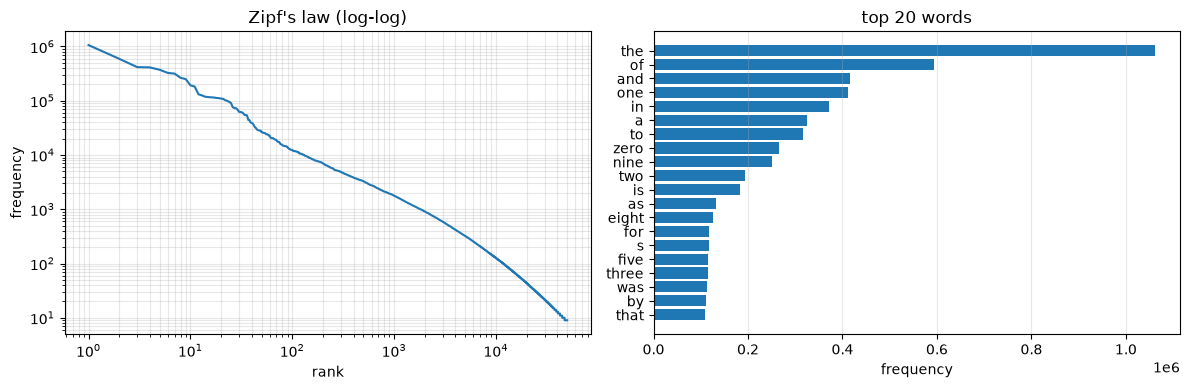

Top 20 : the, of, and, one, in, a, to, zero, nine, two, is, as, eight, for, s, five, three, was, by, that
Rank 5000-5010 : dying, assassinated, wolf, robin, joan, rhythm, lutheran, willing, intention, firing


In [7]:
# Zipf's law sanity check: rank vs frequency should be near-linear on a log-log plot.
ranks = np.arange(1, len(vocab) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(ranks, vocab.counts)
axes[0].set(xlabel="rank", ylabel="frequency", title="Zipf's law (log-log)")
axes[0].grid(alpha=.3, which="both")

top = 20
axes[1].barh(range(top), vocab.counts[:top][::-1])
axes[1].set_yticks(range(top), vocab.itos[:top][::-1])
axes[1].set(xlabel="frequency", title=f"top {top} words")
axes[1].grid(alpha=.3, axis="x")

plt.tight_layout()
plt.show()

print("Top 20 :", ", ".join(vocab.itos[:20]))
print("Rank 5000-5010 :", ", ".join(vocab.itos[5000:5010]))

Note the top of the list: `the`, `of`, `and`, `one`, `in` … These are **stopword-like** — they
co-occur with everything, so they carry almost no distributional information, yet they dominate
the training pairs. Step 7 handles them with *subsampling*.

<a id="3"></a>
## Step 3 — Choose the context window $C$

> *Context window of size 2 words before and after each word, creating 5-word sliding windows.*

With $C = 2$, the window spanning a centre word $w_t$ is

$$[\,w_{t-2},\; w_{t-1},\; \underbrace{w_t}_{\text{target}},\; w_{t+1},\; w_{t+2}\,]$$

giving $2C + 1 = 5$ positions and up to $2C = 4$ (target, context) pairs per centre word.

**Dynamic window.** word2vec does not use a fixed $C$. For each centre word it draws
$b \sim \mathcal{U}\{1, \dots, C\}$ and uses window $b$. A word at distance 1 therefore appears in
every window, while a word at distance $C$ appears in only $1/C$ of them — an implicit
$1/d$ distance weighting, obtained for free with no extra multiplication.

Rule of thumb: **small $C$ (2–5) → syntactic** similarity (`run`/`ran`/`runs`);
**large $C$ (10+) → topical** similarity (`run`/`marathon`/`athlete`).

In [8]:
def windows(tokens: Sequence[int], cfg: Config = CFG,
            rng: np.random.Generator | None = None) -> Iterator[tuple[int, int]]:
    """Yield (target, context) index pairs from an encoded sentence."""
    rng = rng or np.random.default_rng(cfg.seed)
    n = len(tokens)
    for i, target in enumerate(tokens):
        b = int(rng.integers(1, cfg.window + 1)) if cfg.dynamic_window else cfg.window
        lo, hi = max(0, i - b), min(n, i + b + 1)
        for j in range(lo, hi):
            if j != i:
                yield target, tokens[j]

demo_words = "the quick brown fox jumps over the lazy dog".split()
demo_ids = [vocab[w] for w in demo_words if w in vocab]
print("sentence:", " ".join(vocab.itos[i] for i in demo_ids), "\n")
for t, c in windows(demo_ids, Config(**{**asdict(CFG), "dynamic_window": False})):
    print(f"  target={vocab.itos[t]:<8} context={vocab.itos[c]}")

sentence: the quick brown fox jumps over the lazy dog 

  target=the      context=quick
  target=the      context=brown
  target=quick    context=the
  target=quick    context=brown
  target=quick    context=fox
  target=brown    context=the
  target=brown    context=quick
  target=brown    context=fox
  target=brown    context=jumps
  target=fox      context=quick
  target=fox      context=brown
  target=fox      context=jumps
  target=fox      context=over
  target=jumps    context=brown
  target=jumps    context=fox
  target=jumps    context=over
  target=jumps    context=the
  target=over     context=fox
  target=over     context=jumps
  target=over     context=the
  target=over     context=lazy
  target=the      context=jumps
  target=the      context=over
  target=the      context=lazy
  target=the      context=dog
  target=lazy     context=over
  target=lazy     context=the
  target=lazy     context=dog
  target=dog      context=the
  target=dog      context=lazy


<a id="4"></a>
## Step 4 — Build the co-occurrence dictionary

> *For each word, record the words that appear within its context window. This dictionary
> captures how often words appear near each other.*

The dictionary maps `(target, context) -> count`. For the full 17 M-token corpus this would be
hundreds of millions of entries, so we build it over a **sample** — it is a diagnostic here, not a
training input.

> **Design note.** SGNS does *not* need this table: it streams pairs straight from the corpus and
> updates as it goes. That is exactly why word2vec scales to billions of tokens where count-based
> methods (LSA, HAL) do not. The table is built to (a) satisfy the procedure, and (b) let us
> eyeball whether the window logic is producing sensible neighbours.

In [9]:
def build_cooccurrence(path: pathlib.Path, vocab: Vocabulary, cfg: Config = CFG,
                       max_tokens: int = 2_000_000) -> collections.Counter:
    """Count (target, context) pairs over the first `max_tokens` in-vocab tokens."""
    rng = np.random.default_rng(cfg.seed)
    cooc: collections.Counter[tuple[int, int]] = collections.Counter()
    buf: list[int] = []
    seen = 0

    stream = stream_tokens(path, cfg)
    with tqdm(total=max_tokens, desc="co-occurrence", unit=" tok", unit_scale=True) as bar:
        for tok in stream:
            idx = vocab.stoi.get(tok)
            if idx is None:
                continue
            buf.append(idx)
            seen += 1
            bar.update(1)
            if len(buf) >= 10_000:
                cooc.update(windows(buf, cfg, rng))
                buf = buf[-cfg.window:]      # carry the tail so windows span the seam
            if seen >= max_tokens:
                break
    if buf:
        cooc.update(windows(buf, cfg, rng))
    return cooc

t0 = time.time()
cooc = build_cooccurrence(CORPUS_PATH, vocab, CFG)
print(f"\n{len(cooc):,} distinct (target, context) pairs in {time.time() - t0:.1f}s")

co-occurrence: 100%|██████████| 2.00M/2.00M [00:11<00:00, 176k tok/s] 


1,992,128 distinct (target, context) pairs in 11.4s


In [11]:
def top_contexts(word: str, k: int = 10) -> list[tuple[str, int]]:
    """The k words most often seen inside `word`'s window."""
    if word not in vocab:
        return []
    wid = vocab[word]
    hits = [(c, n) for (t, c), n in cooc.items() if t == wid]
    hits.sort(key=lambda x: -x[1])
    return [(vocab.itos[c], n) for c, n in hits[:k]]

for probe in ["king", "computer", "war", "music"]:
    pairs = top_contexts(probe, 8)
    shown = ", ".join(f"{w}({n})" for w, n in pairs) or "(not in vocab)"
    print(f"{probe:<10} -> {shown}")

king       -> of(455), the(340), s(84), and(80), a(49), by(44), i(39), was(38)
computer   -> the(159), and(86), a(76), of(59), apple(47), in(44), science(43), s(30)
war        -> the(770), world(420), of(293), civil(260), ii(251), in(164), and(160), one(119)
music      -> the(88), of(87), and(83), in(49), for(24), s(23), a(22), is(22)


The neighbours are dominated by `the`, `of`, `and` — function words swamp the signal. This is the
concrete reason for **subsampling** in the next section, and it is also why raw co-occurrence
counts make poor embeddings without reweighting (PMI, log-scaling, …).

<a id="5"></a>
## Step 5 — Choose the embedding size $N$

> *Each word is represented by a vector of $N$ numbers (e.g. 300). Larger $N$ captures more
> information but increases training time and memory.*

Memory for both tables is $2 \times M \times N \times 4$ bytes (float32):

| $M$ | $N$ | $E$ + $U$ |
|---|---|---|
| 50,000 | 100 | 40 MB |
| 50,000 | 300 | 120 MB |
| 1,000,000 | 300 | 2.4 GB |

Empirically quality rises steeply to $N \approx 100$, gains slowly to ~300, then plateaus and
eventually *degrades* — a large $N$ on a small corpus has enough capacity to memorise noise.
Rule of thumb: $N \approx 100$ for $10^7$ tokens, $N \approx 300$ for $10^9$.

In [12]:
M, N = len(vocab), CFG.dim
bytes_per_table = M * N * 4
print(f"M (vocab)        {M:,}")
print(f"N (dim)          {N}")
print(f"E parameters     {M * N:,}")
print(f"E + U memory     {2 * bytes_per_table / 1e6:.1f} MB (float32)")

M (vocab)        50,000
N (dim)          100
E parameters     5,000,000
E + U memory     40.0 MB (float32)


<a id="6"></a>
## Step 6 — Initialise the two tables $E$ and $U$

> *Each table has $M$ rows and $N$ columns; each row represents a word.*

Two separate tables, and the asymmetry matters:

| Table | Role | Row $i$ means |
|---|---|---|
| $E$ | **target** / input | "the vector for word $i$ when it is the centre word" |
| $U$ | **context** / output | "the vector for word $i$ when it is a neighbour" |

Why not share one table? With a single table, $\mathbf{e}_w \cdot \mathbf{e}_w = \lVert
\mathbf{e}_w \rVert^2$ is large and positive, so the model is pushed to believe every word is its
own context. Two tables break that degenerate coupling.

**Initialisation.** $E \sim \mathcal{U}(-0.5/N,\ 0.5/N)$ — small random values to break symmetry
(all-zeros would give identical gradients to every row forever). $U = \mathbf{0}$, matching the
reference implementation: every initial dot product is exactly 0, so $\sigma(0) = 0.5$ and the
first gradients are cleanly signed.

In [13]:
class SGNSModel:
    """The two embedding tables plus the negative-sampling noise distribution."""

    def __init__(self, vocab: Vocabulary, cfg: Config = CFG):
        self.vocab, self.cfg = vocab, cfg
        rng = np.random.default_rng(cfg.seed)
        M, N = len(vocab), cfg.dim

        # E: target embeddings — small uniform noise breaks symmetry between rows.
        self.E = ((rng.random((M, N), dtype=np.float32) - 0.5) / N).astype(np.float32)
        # U: context embeddings — zeros, as in the reference word2vec.
        self.U = np.zeros((M, N), dtype=np.float32)

        self._build_noise_table()
        self._build_subsample_table()

    # ---- negative-sampling noise distribution -------------------------------
    def _build_noise_table(self) -> None:
        """P(w) proportional to count(w)^0.75 — flattens Zipf so rare words get sampled."""
        p = self.vocab.counts.astype(np.float64) ** self.cfg.ns_power
        self.noise_p = (p / p.sum()).astype(np.float64)

    # ---- frequent-word subsampling -----------------------------------------
    def _build_subsample_table(self) -> None:
        """P(keep w) = min(1, sqrt(t / f(w)) + t / f(w)) — Mikolov's discard rule."""
        t = self.cfg.subsample_t
        if t <= 0:
            self.keep_p = np.ones(len(self.vocab), dtype=np.float32)
            return
        f = self.vocab.freqs
        self.keep_p = np.minimum(1.0, np.sqrt(t / f) + t / f).astype(np.float32)

    def save(self, path: pathlib.Path) -> None:
        np.savez_compressed(path, E=self.E, U=self.U,
                            itos=np.array(self.vocab.itos, dtype=object),
                            counts=self.vocab.counts)

model = SGNSModel(vocab, CFG)
print(f"E {model.E.shape} {model.E.dtype}   mean={model.E.mean():+.2e} std={model.E.std():.2e}")
print(f"U {model.U.shape} {model.U.dtype}   all zeros: {not model.U.any()}")

E (50000, 100) float32   mean=+1.70e-07 std=2.89e-03
U (50000, 100) float32   all zeros: True


### Two distributions worth inspecting

**Noise distribution $P_n(w) \propto \text{count}(w)^{3/4}$.** Sampling negatives uniformly would
almost never pick a frequent word (so the model never learns to separate `the` from anything);
sampling proportional to raw frequency would pick `the` constantly. The $3/4$ exponent is the
empirical compromise from the paper — it lifts rare words and damps frequent ones.

**Subsampling.** Each occurrence of $w$ is discarded with probability $1 - P(\text{keep }w)$ where

$$P(\text{keep } w) = \min\!\left(1,\ \sqrt{\tfrac{t}{f(w)}} + \tfrac{t}{f(w)}\right)$$

Words rarer than $t$ are always kept; `the` (at $f \approx 6\%$) survives only ~4% of the time.
Two wins: fewer useless `(the, of)` pairs, and shorter effective distances that let real content
words see each other.

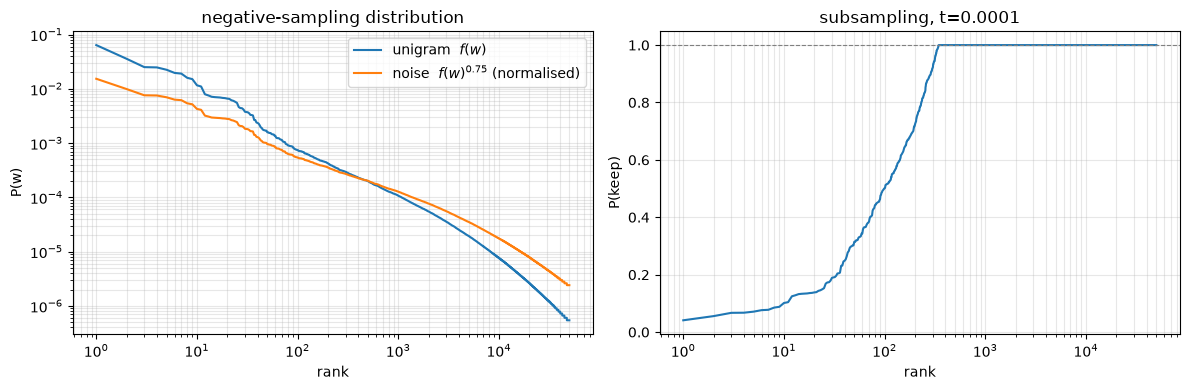

word            freq   P(keep)   noise x uniform
the          0.06399     0.041             766.4x
of           0.03579     0.056             495.7x
one          0.02482     0.067             376.7x
history      0.00076     0.494              27.6x
king         0.00045     0.694              18.6x
philosophy   0.00017     1.000               8.8x
aggadic      0.00000     1.000               0.1x


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

r = np.arange(1, len(vocab) + 1)
axes[0].loglog(r, vocab.freqs, label="unigram  $f(w)$")
axes[0].loglog(r, model.noise_p, label=r"noise  $f(w)^{0.75}$ (normalised)")
axes[0].set(xlabel="rank", ylabel="P(w)", title="negative-sampling distribution")
axes[0].legend(); axes[0].grid(alpha=.3, which="both")

axes[1].semilogx(r, model.keep_p)
axes[1].axhline(1.0, ls="--", c="grey", lw=.8)
axes[1].set(xlabel="rank", ylabel="P(keep)", title=f"subsampling, t={CFG.subsample_t:g}")
axes[1].grid(alpha=.3, which="both")

plt.tight_layout(); plt.show()

print(f"{'word':<10}{'freq':>10}{'P(keep)':>10}{'noise x uniform':>18}")
uniform = 1 / len(vocab)
for w in ["the", "of", "one", "history", "king", "philosophy", vocab.itos[-1]]:
    if w in vocab:
        i = vocab[w]
        print(f"{w:<10}{vocab.freqs[i]:>10.5f}{model.keep_p[i]:>10.3f}"
              f"{model.noise_p[i] / uniform:>18.1f}x")

<a id="7"></a>
## Step 7 — Train with the sliding window

> *Slide a window of size $2C+1$ over the corpus. For each target word fetch $\mathbf{e}$ from $E$
> and each context word $\mathbf{u}$ from $U$. Compute $\mathbf{e} \cdot \mathbf{u}$, apply
> sigmoid. Use gradient descent to move positives toward 1. Also sample 5–10 negatives and move
> those toward 0. Repeat 3–50 times.*

### The gradients, derived

Let $s = \mathbf{e}_w \cdot \mathbf{u}_c$ and $\hat{y} = \sigma(s)$. Define the label $y = 1$ for a
true context pair, $y = 0$ for a sampled negative. The per-pair loss is binary cross-entropy:

$$\mathcal{L} = -\big[\,y \log \hat{y} + (1-y)\log(1-\hat{y})\,\big]$$

Because $\sigma'(s) = \sigma(s)(1 - \sigma(s))$, the chain rule collapses to a single subtraction:

$$\frac{\partial \mathcal{L}}{\partial s} = \hat{y} - y \;\equiv\; g$$

and therefore

$$\boxed{\;\frac{\partial \mathcal{L}}{\partial \mathbf{e}_w} = g\,\mathbf{u}_c
\qquad
\frac{\partial \mathcal{L}}{\partial \mathbf{u}_c} = g\,\mathbf{e}_w\;}$$

The SGD update is then just $\mathbf{e} \mathrel{-}= \eta\, g\, \mathbf{u}$ and
$\mathbf{u} \mathrel{-}= \eta\, g\, \mathbf{e}$. That is the entire learning rule — one sigmoid,
one subtraction, two scaled vector adds.

**Read the sign.** For a positive pair $g = \hat{y} - 1 < 0$, so $\mathbf{e}$ moves *along*
$\mathbf{u}$ — the vectors rotate together. For a negative $g = \hat{y} > 0$, so $\mathbf{e}$ moves
*away* from $\mathbf{u}$. Attraction and repulsion, from one formula.

In [15]:
def sigmoid(x: np.ndarray, max_exp: float = CFG.max_exp) -> np.ndarray:
    """Numerically safe sigmoid: clipping also caps the gradient magnitude."""
    return 1.0 / (1.0 + np.exp(-np.clip(x, -max_exp, max_exp)))

# Verify the collapsed gradient against a finite-difference check.
rng = np.random.default_rng(0)
e = rng.normal(size=8).astype(np.float64)
u = rng.normal(size=8).astype(np.float64)

def loss(e, u, y):
    p = float(sigmoid(np.array(e @ u)))
    return -(y * math.log(p) + (1 - y) * math.log(1 - p))

for y in (1.0, 0.0):
    g = float(sigmoid(np.array(e @ u))) - y
    analytic = g * u
    eps = 1e-6
    numeric = np.array([(loss(e + eps * np.eye(8)[i], u, y)
                         - loss(e - eps * np.eye(8)[i], u, y)) / (2 * eps) for i in range(8)])
    print(f"y={y:.0f}  max |analytic - numeric| = {np.abs(analytic - numeric).max():.2e}")

y=1  max |analytic - numeric| = 1.82e-10
y=0  max |analytic - numeric| = 8.67e-11


Agreement to ~$10^{-9}$ — the derivation is right.

### Why the batch is *ragged*

A naive loop does one pair at a time: pure Python, ~50 K pairs/sec. Instead we process
`batch_pairs` centre words at once. Each centre word contributes a different number of contexts
(dynamic window, sentence edges), so the batch is ragged; we flatten it into three parallel arrays

```
targets  = [w0, w0, w1, w2, w2, w2, ...]   # repeated per context
contexts = [c0, c1, c2, c3, c4, c5, ...]
```

and do the whole batch as matrix ops. Each positive row gets $k$ negatives drawn from
$P_n$, giving a `(P, k)` block handled with one `einsum`.

**Duplicate rows.** Flattening means the same word index can appear several times in one batch.
`E[idx] -= grad` would then silently apply only the *last* write, so we use
`np.add.at`, which accumulates. Getting this wrong is the classic vectorised-word2vec bug: it
trains, the loss falls, and the vectors are quietly wrong.

In [16]:
def encode_and_subsample(path: pathlib.Path, vocab: Vocabulary, model: SGNSModel,
                         cfg: Config, rng: np.random.Generator,
                         chunk: int = 200_000) -> Iterator[np.ndarray]:
    """Stream the corpus as arrays of in-vocab ids with frequent words subsampled out."""
    buf: list[int] = []
    for tok in stream_tokens(path, cfg):
        idx = vocab.stoi.get(tok)
        if idx is None:
            continue
        buf.append(idx)
        if len(buf) >= chunk:
            ids = np.fromiter(buf, dtype=np.int32, count=len(buf))
            keep = rng.random(ids.size) < model.keep_p[ids]
            yield ids[keep]
            buf.clear()
    if buf:
        ids = np.fromiter(buf, dtype=np.int32, count=len(buf))
        yield ids[rng.random(ids.size) < model.keep_p[ids]]


def make_pairs(ids: np.ndarray, cfg: Config, rng: np.random.Generator
               ) -> tuple[np.ndarray, np.ndarray]:
    """Vectorised sliding window: return flat (targets, contexts) arrays.

    For each offset d in 1..C we take the whole array shifted by d, which gives every
    (i, i+d) pair at once, then mask out the ones whose dynamic window b < d.
    """
    n = ids.size
    if n < 2:
        empty = np.empty(0, dtype=np.int32)
        return empty, empty

    if cfg.dynamic_window:
        b = rng.integers(1, cfg.window + 1, size=n)     # per-centre-word window size
    else:
        b = np.full(n, cfg.window)

    tgt_parts, ctx_parts = [], []
    for d in range(1, cfg.window + 1):
        # right neighbours: centre i, context i+d
        left_idx = np.arange(0, n - d)
        mask = b[left_idx] >= d
        tgt_parts.append(ids[left_idx[mask]])
        ctx_parts.append(ids[left_idx[mask] + d])

        # left neighbours: centre i+d, context i  (window is symmetric)
        right_idx = np.arange(d, n)
        mask = b[right_idx] >= d
        tgt_parts.append(ids[right_idx[mask]])
        ctx_parts.append(ids[right_idx[mask] - d])

    return (np.concatenate(tgt_parts).astype(np.int32),
            np.concatenate(ctx_parts).astype(np.int32))

# Sanity check against the scalar reference implementation from Step 3.
_cfg_static = Config(**{**asdict(CFG), "dynamic_window": False})
_ids = np.array(demo_ids, dtype=np.int32)
_vec = set(zip(*make_pairs(_ids, _cfg_static, np.random.default_rng(0))))
_ref = set(windows(demo_ids, _cfg_static))
print("vectorised windows match scalar reference:", _vec == _ref, f"({len(_ref)} pairs)")

vectorised windows match scalar reference: True (30 pairs)


In [ ]:
def train_batch(model: SGNSModel, targets: np.ndarray, contexts: np.ndarray,
                lr: float, rng: np.random.Generator) -> float:
    """One SGD step over a flat batch of positive pairs. Returns mean loss."""
    cfg = model.cfg
    P, k = targets.size, cfg.negatives
    if P == 0:
        return 0.0

    E, U = model.E, model.U
    e = E[targets]                                    # (P, N) target vectors

    # ---------- positive pairs ------------------------------------------------
    u_pos = U[contexts]                               # (P, N)
    s_pos = np.einsum("ij,ij->i", e, u_pos)           # (P,)  row-wise dot product
    p_pos = sigmoid(s_pos, cfg.max_exp)
    g_pos = (p_pos - 1.0).astype(np.float32)          # dL/ds, label y = 1

    # ---------- negative pairs ------------------------------------------------
    neg = rng.choice(len(model.vocab), size=(P, k), p=model.noise_p).astype(np.int32)
    u_neg = U[neg]                                    # (P, k, N)
    s_neg = np.einsum("ij,ikj->ik", e, u_neg)         # (P, k)
    p_neg = sigmoid(s_neg, cfg.max_exp)
    g_neg = p_neg.astype(np.float32)                  # dL/ds, label y = 0

    # ---------- gradients -----------------------------------------------------
    # dL/de = g_pos * u_pos + sum_k g_neg * u_neg
    grad_e = g_pos[:, None] * u_pos + np.einsum("ik,ikj->ij", g_neg, u_neg)
    grad_u_pos = g_pos[:, None] * e                   # (P, N)
    grad_u_neg = g_neg[:, :, None] * e[:, None, :]    # (P, k, N)

    # ---------- SGD update ----------------------------------------------------
    # np.add.at (not `-=`) because indices repeat within a batch and must accumulate.
    np.add.at(E, targets, (-lr * grad_e).astype(np.float32))
    np.add.at(U, contexts, (-lr * grad_u_pos).astype(np.float32))
    np.add.at(U, neg.ravel(), (-lr * grad_u_neg).reshape(-1, cfg.dim).astype(np.float32))

    # ---------- loss (monitoring only) ---------------------------------------
    eps = 1e-10
    loss = -(np.log(p_pos + eps).sum() + np.log(1.0 - p_neg + eps).sum())
    return float(loss / P)

In [ ]:
def train(model: SGNSModel, path: pathlib.Path, cfg: Config = CFG) -> list[float]:
    """Full training loop: `cfg.epochs` passes over the corpus."""
    rng = np.random.default_rng(cfg.seed)
    history: list[float] = []

    # Total pairs is unknown up front (subsampling is stochastic), so estimate for lr decay.
    est_pairs = int(vocab.total_kept_tokens * 2 * (cfg.window + 1) / 2 * 0.6) * cfg.epochs
    done = 0
    min_lr = cfg.lr * cfg.min_lr_frac

    for epoch in range(1, cfg.epochs + 1):
        run_loss, run_pairs, batches = 0.0, 0, 0
        bar = tqdm(desc=f"epoch {epoch}/{cfg.epochs}", unit=" pair", unit_scale=True)

        for ids in encode_and_subsample(path, model.vocab, model, cfg, rng):
            targets, contexts = make_pairs(ids, cfg, rng)

            for start in range(0, targets.size, cfg.batch_pairs):
                sl = slice(start, start + cfg.batch_pairs)
                bt, bc = targets[sl], contexts[sl]

                lr = max(min_lr, cfg.lr * (1.0 - done / max(est_pairs, 1)))
                run_loss += train_batch(model, bt, bc, lr, rng) * bt.size
                run_pairs += bt.size
                done += bt.size
                batches += 1

                bar.update(bt.size)
                if batches % 50 == 0:
                    bar.set_postfix(loss=f"{run_loss / max(run_pairs, 1):.4f}", lr=f"{lr:.5f}")

        bar.close()
        epoch_loss = run_loss / max(run_pairs, 1)
        history.append(epoch_loss)
        print(f"  epoch {epoch}: mean loss {epoch_loss:.4f} over {run_pairs:,} pairs")

    return history

t0 = time.time()
history = train(model, CORPUS_PATH, CFG)
print(f"\ntrained in {(time.time() - t0) / 60:.1f} min")

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(history) + 1), history, marker="o")
plt.xlabel("epoch"); plt.ylabel("mean SGNS loss")
plt.title("training loss"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

<a id="8"></a>
## Step 8 — $E$ holds the embeddings; $U$ can be discarded

> *$E$ contains the desired embeddings. $U$ can be discarded.*

$U$ was scaffolding: it existed only to give the dot products something to be scored against. The
knowledge we want — that `king` and `queen` appear in similar company — is entirely in $E$.

For similarity we compare **directions**, not magnitudes: a word's vector norm mostly tracks its
frequency, which is not the property we care about. So we L2-normalise every row and use cosine
similarity, which then reduces to a plain dot product:

$$\cos(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}
{\lVert \mathbf{a} \rVert\, \lVert \mathbf{b} \rVert}$$

In [ ]:
class Embeddings:
    """Read-only query interface over the trained target table E."""

    def __init__(self, E: np.ndarray, itos: Sequence[str]):
        self.itos = list(itos)
        self.stoi = {w: i for i, w in enumerate(self.itos)}
        self.E = np.asarray(E, dtype=np.float32)
        norms = np.linalg.norm(self.E, axis=1, keepdims=True)
        self.En = self.E / np.maximum(norms, 1e-8)     # unit rows -> dot == cosine

    def __contains__(self, w: str) -> bool:
        return w in self.stoi

    def vec(self, w: str, normed: bool = True) -> np.ndarray:
        if w not in self.stoi:
            raise KeyError(f"{w!r} is not in the vocabulary")
        return (self.En if normed else self.E)[self.stoi[w]]

    def similarity(self, a: str, b: str) -> float:
        return float(self.vec(a) @ self.vec(b))

    def most_similar(self, word: str, k: int = 10) -> list[tuple[str, float]]:
        if word not in self.stoi:
            return []
        scores = self.En @ self.vec(word)
        scores[self.stoi[word]] = -np.inf                 # never return the query itself
        top = np.argpartition(-scores, k)[:k]
        top = top[np.argsort(-scores[top])]
        return [(self.itos[i], float(scores[i])) for i in top]

    def analogy(self, a: str, b: str, c: str, k: int = 5) -> list[tuple[str, float]]:
        """a : b :: c : ?   e.g. analogy('man', 'king', 'woman') -> queen"""
        missing = [w for w in (a, b, c) if w not in self.stoi]
        if missing:
            raise KeyError(f"not in vocabulary: {missing}")
        target = self.vec(b) - self.vec(a) + self.vec(c)
        target /= max(float(np.linalg.norm(target)), 1e-8)
        scores = self.En @ target
        for w in (a, b, c):
            scores[self.stoi[w]] = -np.inf                # exclude the inputs
        top = np.argpartition(-scores, k)[:k]
        top = top[np.argsort(-scores[top])]
        return [(self.itos[i], float(scores[i])) for i in top]

    def save(self, path: pathlib.Path) -> None:
        """Write in word2vec text format: '<M> <N>' header, then 'word v1 v2 ...' rows."""
        with path.open("w", encoding="utf-8") as fh:
            fh.write(f"{len(self.itos)} {self.E.shape[1]}\n")
            for w, v in zip(self.itos, self.E):
                fh.write(w + " " + " ".join(f"{x:.5f}" for x in v) + "\n")

    @classmethod
    def load(cls, path: pathlib.Path) -> "Embeddings":
        with path.open("r", encoding="utf-8") as fh:
            m, n = map(int, fh.readline().split())
            words, rows = [], np.empty((m, n), dtype=np.float32)
            for i, line in enumerate(fh):
                w, *vals = line.rstrip("\n").split(" ")
                words.append(w)
                rows[i] = np.asarray(vals, dtype=np.float32)
        return cls(rows, words)

emb = Embeddings(model.E, vocab.itos)          # U is not passed on — discarded, per Step 8
print(f"Embeddings ready: {emb.E.shape[0]:,} words x {emb.E.shape[1]} dims")

## Evaluation

### Nearest neighbours

The primary qualitative test: do a word's closest vectors look like words you would expect to see
in the same sentence slot?

In [ ]:
PROBES = ["king", "computer", "war", "music", "france", "three", "physics", "river"]

for w in PROBES:
    if w not in emb:
        print(f"{w:<10} (not in vocabulary)")
        continue
    neigh = ", ".join(f"{n} {s:.2f}" for n, s in emb.most_similar(w, 8))
    print(f"{w:<10} {neigh}")

### Word analogies

The famous result: **offsets in embedding space encode relations**. If the vector difference
`king - man` really captures "royalty", then adding it to `woman` should land near `queen`.

$$\mathbf{v}_{\text{king}} - \mathbf{v}_{\text{man}} + \mathbf{v}_{\text{woman}} \approx \mathbf{v}_{\text{queen}}$$

Nothing in the loss function asked for this. It falls out of the distributional structure.

In [ ]:
ANALOGIES = [
    ("man", "king", "woman"),           # gender
    ("france", "paris", "italy"),        # capital
    ("good", "better", "bad"),           # comparative
    ("walk", "walked", "run"),           # tense
    ("man", "men", "woman"),             # plural
]

for a, b, c in ANALOGIES:
    try:
        top = emb.analogy(a, b, c, 5)
    except KeyError as err:
        print(f"{a}:{b} :: {c}:?   skipped — {err}")
        continue
    guesses = ", ".join(f"{w} ({s:.2f})" for w, s in top)
    print(f"{a}:{b} :: {c}:?   ->  {guesses}")

### Odd-one-out

Given a set, the outlier is the word furthest from the set's centroid — a quick check that the
space has coherent topical structure.

In [ ]:
def odd_one_out(words: Sequence[str]) -> str | None:
    known = [w for w in words if w in emb]
    if len(known) < 3:
        return None
    mat = np.stack([emb.vec(w) for w in known])
    centroid = mat.mean(axis=0)
    centroid /= max(float(np.linalg.norm(centroid)), 1e-8)
    return known[int(np.argmin(mat @ centroid))]

for group in [
    ["breakfast", "lunch", "dinner", "computer"],
    ["france", "germany", "italy", "guitar"],
    ["red", "blue", "green", "physics"],
    ["january", "february", "march", "river"],
]:
    print(f"{str(group):<52} odd -> {odd_one_out(group)}")

### The space itself

Two views. **Left:** a similarity heatmap over hand-picked words from three semantic fields — if
training worked, bright blocks appear along the diagonal. **Right:** a 2-D PCA projection.

PCA keeps only the two highest-variance directions out of $N$, so read it as a rough sketch, not
evidence — distant points are genuinely distant, but nearby points are not necessarily similar.

In [ ]:
GROUPS = {
    "royalty":  ["king", "queen", "prince", "emperor", "throne"],
    "science":  ["physics", "chemistry", "mathematics", "theory", "equation"],
    "geography":["france", "germany", "italy", "london", "river"],
}
words = [w for g in GROUPS.values() for w in g if w in emb]

if len(words) >= 4:
    mat = np.stack([emb.vec(w) for w in words])
    sim = mat @ mat.T

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    im = axes[0].imshow(sim, cmap="RdYlBu_r", vmin=-1, vmax=1)
    axes[0].set_xticks(range(len(words)), words, rotation=90, fontsize=8)
    axes[0].set_yticks(range(len(words)), words, fontsize=8)
    axes[0].set_title("cosine similarity")
    fig.colorbar(im, ax=axes[0], fraction=.046)

    centred = mat - mat.mean(axis=0)
    _, _, vt = np.linalg.svd(centred, full_matrices=False)
    xy = centred @ vt[:2].T

    colours = plt.cm.tab10(np.linspace(0, 1, len(GROUPS)))
    for (name, members), colour in zip(GROUPS.items(), colours):
        idx = [words.index(w) for w in members if w in words]
        if idx:
            axes[1].scatter(xy[idx, 0], xy[idx, 1], s=60, color=colour, label=name)
    for w, (x, y) in zip(words, xy):
        axes[1].annotate(w, (x, y), fontsize=8, xytext=(4, 4), textcoords="offset points")
    axes[1].set(title="PCA projection (2 of %d dims)" % emb.E.shape[1],
                xlabel="PC 1", ylabel="PC 2")
    axes[1].legend(); axes[1].grid(alpha=.3)

    plt.tight_layout(); plt.show()
else:
    print("not enough probe words in vocabulary to plot")

## Persist the artifacts

Saved to `artifacts/`:

| File | Contents |
|---|---|
| `embeddings.txt` | $E$ in word2vec text format — loadable by `gensim`, `KeyedVectors`, etc. |
| `model.npz` | Both tables plus the vocabulary, for resuming training |
| `config.json` | Every hyperparameter used in this run |

In [ ]:
emb.save(ARTIFACTS / "embeddings.txt")
model.save(ARTIFACTS / "model.npz")
CFG.save(ARTIFACTS / "config.json")

for f in sorted(ARTIFACTS.glob("*")):
    if f.suffix != ".zip":
        print(f"{f.name:<20} {f.stat().st_size / 1e6:>8.2f} MB")

# Round-trip check: reload from disk and confirm the vectors survive.
reloaded = Embeddings.load(ARTIFACTS / "embeddings.txt")
probe = next(w for w in PROBES if w in emb)
print(f"\nreload check on {probe!r}: "
      f"cos(original, reloaded) = {float(emb.vec(probe) @ reloaded.vec(probe)):.6f}")

## Discussion

### What each step actually bought us

| Step | Decision | Consequence if skipped |
|---|---|---|
| 2 | `min_count = 5` | Thousands of noise vectors fitted to 1–2 observations |
| 3 | dynamic window | Distant words weighted as heavily as adjacent ones |
| 5 | $N = 100$ | Too small: underfits. Too large: memorises noise |
| 6 | separate $E$, $U$ | Shared table makes every word its own best context |
| 7 | subsampling | `the`, `of`, `and` dominate; content words barely train |
| 7 | $f^{0.75}$ noise | Uniform negatives never include frequent words |
| 7 | negative sampling | Full softmax over $M$ = $O(M)$ per pair — intractable |

### Why negative sampling at all

The "correct" objective is a softmax over the whole vocabulary:

$$P(c \mid w) = \frac{\exp(\mathbf{e}_w \cdot \mathbf{u}_c)}{\sum_{c'=1}^{M} \exp(\mathbf{e}_w \cdot \mathbf{u}_{c'})}$$

That denominator costs $O(M)$ per training pair — with $M = 50{,}000$ and $10^8$ pairs, hopeless.
Negative sampling replaces the multi-class problem with $k+1$ independent binary ones, dropping the
cost to $O(k)$ with $k \approx 5$: a **four-order-of-magnitude** speedup with negligible quality
loss. Levy & Goldberg (2014) later showed SGNS is implicitly factorising a shifted PMI matrix,
which is why it behaves like a count-based method while training like a streaming one.

### Known limitations

* **One vector per word type** — `bank` (river) and `bank` (money) collapse into one vector.
  Contextual models (ELMo, BERT) exist precisely to fix this.
* **No subword information** — an unseen word has no vector at all. FastText adds character
  $n$-grams to solve this.
* **Corpus bias is learned faithfully.** The analogy machinery that produces `king - man + woman
  = queen` also produces stereotyped associations present in the training text. This is a property
  of the data, reproduced without comment by the algorithm.

### References

1. Mikolov, Sutskever, Chen, Corrado & Dean (2013). *Distributed Representations of Words and
   Phrases and their Compositionality.* NeurIPS. — negative sampling, subsampling, $f^{0.75}$.
2. Mikolov, Chen, Corrado & Dean (2013). *Efficient Estimation of Word Representations in Vector
   Space.* ICLR. — the skip-gram and CBOW architectures.
3. Goldberg & Levy (2014). *word2vec Explained.* arXiv:1402.3722. — the gradient derivation above.
4. Levy & Goldberg (2014). *Neural Word Embedding as Implicit Matrix Factorization.* NeurIPS.